# Sales Analysis Project

# Dataset: Cleaned Sales Data
# Goal: Explore revenue patterns across time, category, region, and discount

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

sns.set_style("whitegrid")
sns.set_palette("muted")

df = pd.read_parquet(os.path.join("..", "data", "processed", "cleaned_sales_dataset.parquet"))
df.head()


,date,category,region,channel,payment_method,units_sold,sales_amount,discount_pct,customer_rating
0,2023-01-14,Sports,East,Wholesale,Cash,15,2969.58,22.0,2.9
1,2022-04-25,Books,Central,Retail,PayPal,346,27694.24,28.0,3.8
2,2023-10-05,Clothing,South,Direct,Credit Card,244,2010.05,47.0,3.7
3,2023-06-06,Furniture,South,Retail,Debit Card,95,19801.77,38.0,4.5
4,2023-12-21,Food,South,Wholesale,Credit Card,384,114936.53,38.0,3.5


## Goal :- Explore how do monthly sales over time 
Aggregating monthy total sales- to analyze the growth pattern

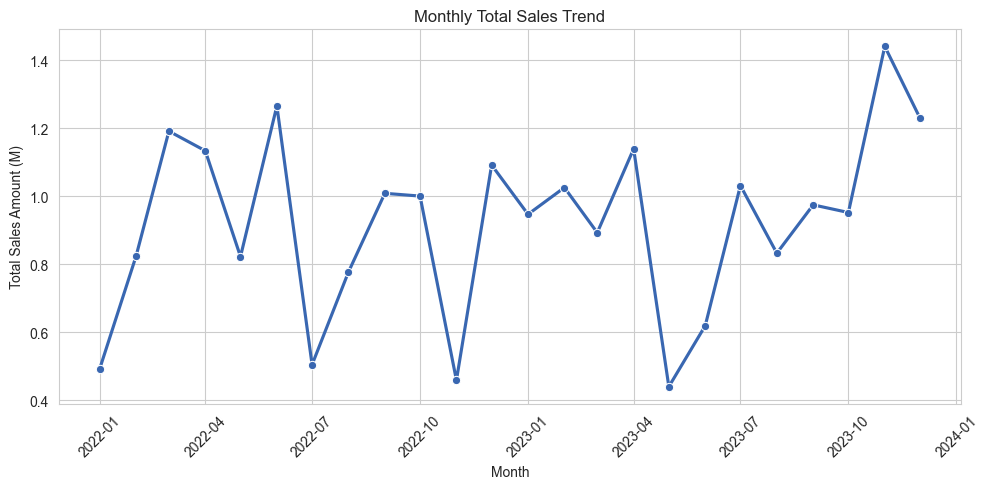

In [14]:
# ---LINE PLOT----
plt.figure(figsize=(10, 5))

# Aggregate - using plot_df to avoid mutating original df
plot_df = df[df['date'] < '2024-01-01'].copy()
plot_df['month'] = plot_df['date'].dt.to_period('M')
monthly_sales = plot_df.groupby('month')['sales_amount'].sum().reset_index()

# converting Period to timestamp so seaborn can plot it on x-axis
monthly_sales['month'] = monthly_sales['month'].dt.to_timestamp()

# converting to millions for cleaner y-axis labels
monthly_sales['sales_millions'] = monthly_sales['sales_amount'] / 1e6

# plotting
sns.lineplot(x='month', y='sales_millions', data=monthly_sales,
             color="#3967B1", linewidth=2.25, marker="o")

plt.title('Monthly Total Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales Amount (M)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../assets/monthly_sales_trend.png", dpi=150, bbox_inches='tight')
plt.show()

### Insight
Highest total sale was seen in october 2023 around 1.4M
Typical monthly sales is around ~1M
January 2024 has only one recorded data point so the monthly aggregation is incomplete and misleading

## Goal:- which product category give the most revenue
Aggregating category,revenue with total sales to know which category gives the most sale and in which region

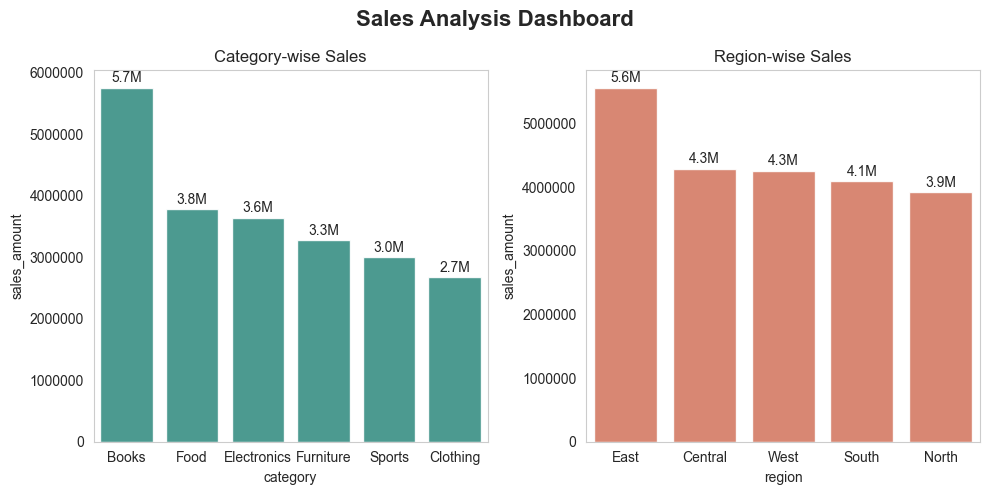

In [15]:
# ---BAR PLOT---
# comparing two barplot plots (category and region) side by side 
# to identify which one drive revenue
category_sales=df.groupby('category')['sales_amount'].sum().reset_index()
category_sales = category_sales.sort_values('sales_amount', ascending=False)

region_sales=df.groupby('region')['sales_amount'].sum().reset_index()
region_sales=region_sales.sort_values('sales_amount',ascending=False)

fig,(ax1,ax2)=plt.subplots(nrows=1,ncols=2,figsize=(10,5))

sns.barplot(
    x='category',
    y='sales_amount',
    data=category_sales,
    color="#2A9D8F",
    alpha=0.9,
    ax=ax1
)
ax1.ticklabel_format(style='plain', axis='y')
for p in ax1.patches:
    value = p.get_height()
    
    ax1.annotate(
        f'{value/1_000_000:.1f}M',
        (p.get_x() + p.get_width() / 2., value * 1.01),
        ha='center',
        va='bottom'
    )
ax1.grid(axis='y')

sns.barplot(
    x='region',
    y='sales_amount',
    data=region_sales,
    color="#E76F51",
    alpha=0.9,
    ax=ax2
)
ax2.ticklabel_format(style='plain', axis='y')
for p in ax2.patches:
    value = p.get_height()
    ax2.annotate(
        f'{value/1_000_000:.1f}M',
        (p.get_x() + p.get_width() / 2., value * 1.01),
        ha='center',
        va='bottom'
    )
ax2.grid(axis='y')

fig.suptitle("Sales Analysis Dashboard", fontsize=16, fontweight='bold')
ax1.set_title("Category-wise Sales", fontsize=12)
ax2.set_title("Region-wise Sales", fontsize=12)
plt.tight_layout()
plt.savefig("../assets/category_vs_region _revenue.png", dpi=72, bbox_inches='tight')
plt.show()

#### Insight:
Book category is dominating in the total sale per category bar
5.7M total sales of book-outperforming other categories
This indicate strong customer demand in the book category
The business appears to be heavily driven by books category
Whereas in region wise the East region gives the highest sales (~5.6M)
This indicate that the people in the East region are more active and sales are high there

## Goal:- To analyze the trend between the sale and discount
As discount applies then sales increase or not

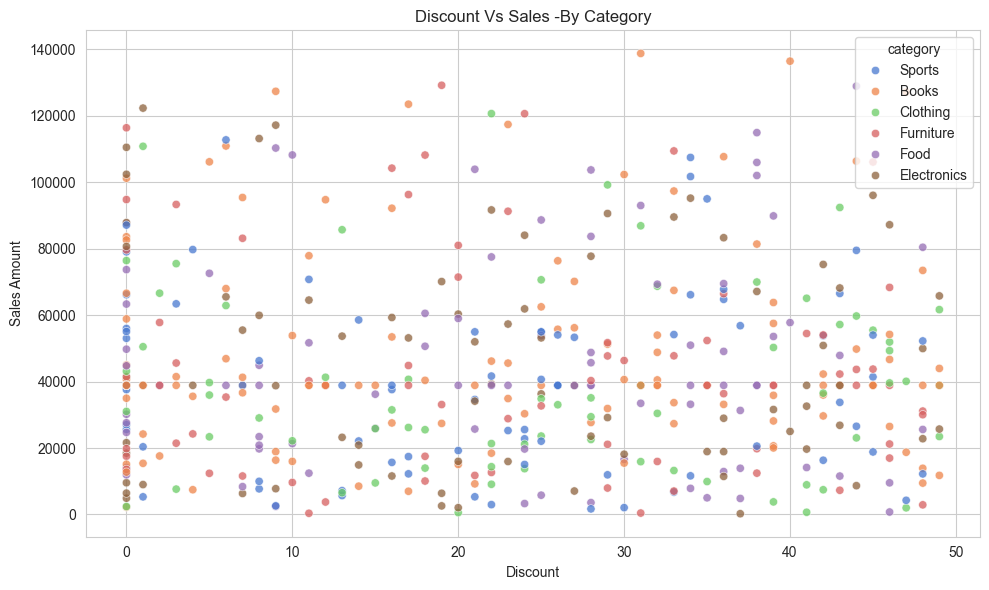

In [16]:
# ---SCATTER PLOT---
# scatterplot - to analyze the trends between the sales_amount and discount_pct
# To explore that sales increasing when discount applies
plt.figure(figsize=(10, 6))
sns.scatterplot(x='discount_pct',y='sales_amount',data=df,hue='category',alpha=0.75)
plt.xlabel("Discount")
plt.ylabel("Sales Amount")
plt.title("Discount Vs Sales -By Category")
plt.tight_layout()
plt.savefig("../assets/discount_vs_sales.png", dpi=150, bbox_inches='tight')

plt.show()

### Insight
There is no clear relationship between the discount and sales
As values are scattered all over 
Even the highest discount sales does not increase constantly
This shows that discount is not alone the cause factor

## Goal:- How sales amount is distributed across category
Using a boxplot to compare median sales, spread, and outliers per category.

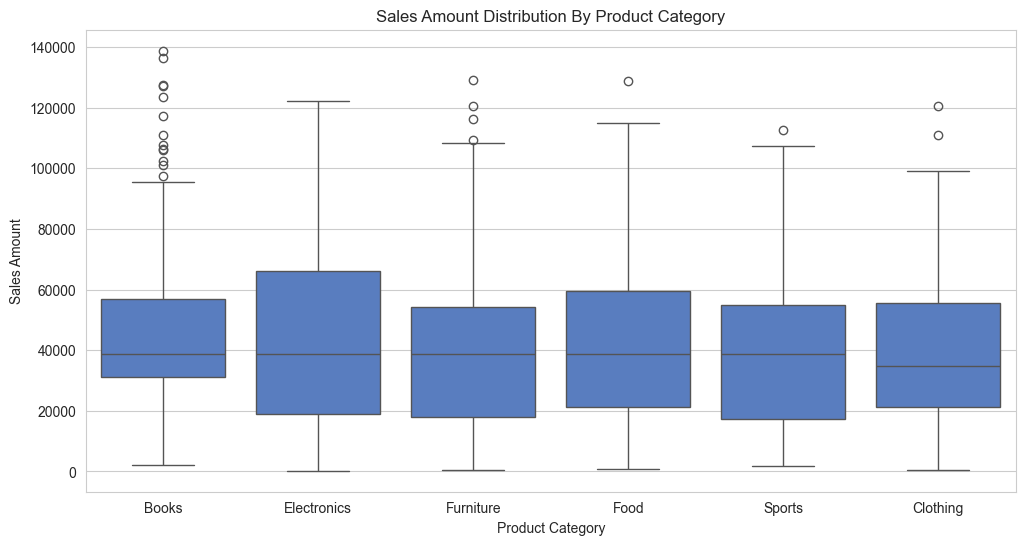

In [17]:
# ---BOX PLOT---
order = df.groupby('category')['sales_amount'].median().sort_values(ascending=False).index
plt.figure(figsize=(12, 6))
sns.boxplot(data=df,order=order,x='category',y='sales_amount')
plt.xlabel('Product Category')
plt.ylabel("Sales Amount")
plt.title('Sales Amount Distribution By Product Category')
plt.savefig("../assets/sales_boxplot_category.png", dpi=150, bbox_inches='tight')
plt.show()

### Insight
Electronic shows the highest median sales
Electronic also have wider spread ,indicating more variability in sales performance
Most category has outliers,suggesting occasional high value transactions
So overall sales are not evenly distributed ,some category are more consistent while other fluctuate

## Goal:-To know overall distribution of sales amount
Using log transformation to reduce skewness and improve model training

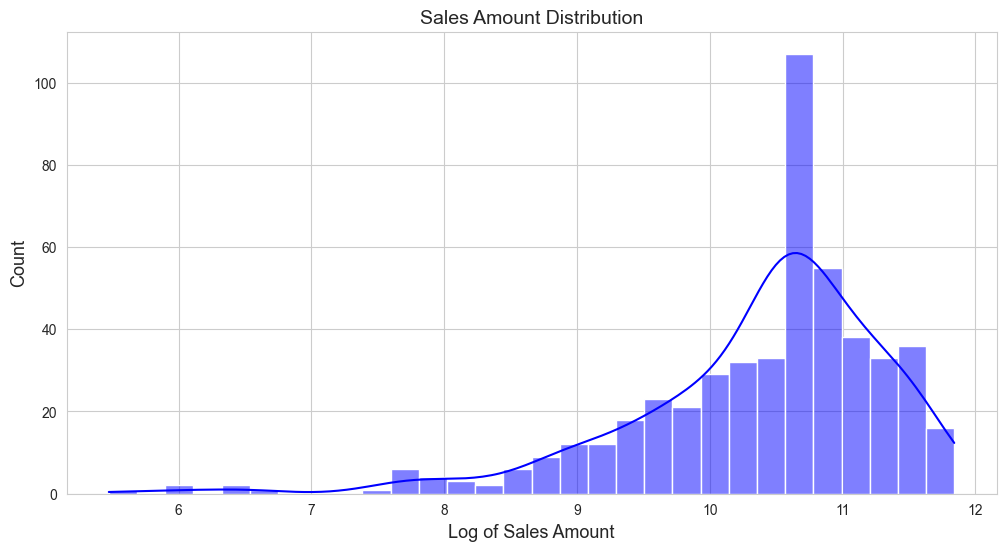

In [18]:
# ---HIST PLOT---
# histplot- to know how data is distributed
plt.figure(figsize=(12,6))
sns.histplot(data=df,x=np.log1p(df['sales_amount']),bins=30,kde=True,color='blue')
plt.title('Sales Amount Distribution',fontsize=14)
plt.xlabel("Log of Sales Amount",fontsize=13)
plt.ylabel("Count",fontsize=13)
plt.savefig("../assets/sales_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

### Insight
After applying log transformation the sale distribution appear more normally distributed and less skewed
Most values are concentrated around middle range with few extreme values
This says that the orignal data was right skewed with some large outliers 
Using log transformation makes data less skewed and more normally distributed make it suitable for model training

## Summary of Findings

| Analysis | Finding |
|---|---|
| Monthly Trend | Sales peaked in October 2023 at ~1.4M. Typical monthly sales ~1M. |
| Category vs Region | Books lead at 5.7M. East region leads at ~5.6M. |
| Discount vs Sales | No clear correlation. Discount alone does not drive sales. |
| Category Distribution | Electronics has highest median with widest spread. Most categories show outliers. |
| Sales Distribution | Data was right-skewed. Log transformation produces near-normal distribution. |

**Tools Used:** Python, Pandas, Matplotlib, Seaborn